In [1]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from lightkurve.correctors import CBVCorrector

from astropy.coordinates import SkyCoord

from multiprocessing import Pool

from tqdm import tqdm
import os
import glob
import shutil
import time
from copy import deepcopy

from Kakapo.build_epsf import epsf_data_creation
from Kakapo.kakapo import Kakapo
from Kakapo.send_myself_email import send_mail
from Kakapo.cleaning_curve import gauss_smooth
# from Kakapo.difference_image import create_diff_image
from Kakapo.photometry import forced_photometry

from photutils.aperture import RectangularAperture, RectangularAnnulus,CircularAperture, CircularAnnulus
from photutils.aperture import ApertureStats, aperture_photometry
from photutils.psf import extract_stars, EPSFStars, EPSFBuilder

from astropy.time import Time

from scipy.ndimage import shift
from scipy.signal import find_peaks

import warnings

warnings.filterwarnings('ignore')

%matplotlib widget

In [2]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# plt.rc('font', size=13)
# plt.rc('xtick', labelsize=13)
# plt.rc('ytick', labelsize=13)

fig_width_pt = 244.0  # Get this from LaTeX using \the\columnwidth
text_width_pt = 508.0 # Get this from LaTeX using \the\textwidth

inches_per_pt = 1.0/72.27               # Convert pt to inches
golden_mean = (np.sqrt(5)-1.0)/2.0         # Aesthetic ratio
fig_width = fig_width_pt*inches_per_pt*1.5 # width in inches
fig_width_full = text_width_pt*inches_per_pt  # 17
fig_height =fig_width*golden_mean # height in inches
fig_size = [fig_width,fig_height] #(9,5.5) #(9, 4.5)

In [3]:
def _tpf_addition(tpf_info, tpf_input):
    
    if tpf_input.campaign is None:
        campaign = tpf_input.quarter
        mission = 'Kepler'
        print(f"Adding TPF {tpf_input.targetid} from {mission} quarter {campaign}")
    else:
        campaign = tpf_input.campaign
        mission = 'K2'
    
    tpf_info.loc[len(tpf_info)] = [mission, campaign, tpf_input.targetid, tpf_input.ra, tpf_input.dec, 
                                   tpf_input.flux.value, tpf_input.flux_err.value, tpf_input.quality, 
                                   tpf_input.pos_corr1, tpf_input.pos_corr2, tpf_input.time]
    
    return tpf_info
        
def _check_tpf_type(tpf_input):
    
    tpf_info = pd.DataFrame(columns=['mission', 'campaign', 'targetid', 'ra', 'dec', 'flux', 'flux_err', 
                                     'quality', 'pos_corr1', 'pos_corr2', 'time'])
    
    if isinstance(tpf_input, lk.targetpixelfile.KeplerTargetPixelFile):
        tpf_info = _tpf_addition(tpf_info, tpf_input)
    
    elif isinstance(tpf_input, str):
        tpf_input = lk.open(tpf_input, quality_bitmask = 'none')
        tpf_info = _tpf_addition(tpf_info, tpf_input)
    
    elif isinstance(tpf_input, lk.collections.TargetPixelFileCollection):
        tpf_input_list = deepcopy(tpf_input)
        
        for i in range(len(tpf_input)):
            tpf_info = _tpf_addition(tpf_info, tpf_input_list[i])
            
    elif isinstance(tpf_input, list):
        tpf_input_list = deepcopy(tpf_input)
        
        for i in range(len(tpf_input)):
            if isinstance(tpf_input_list[i], lk.targetpixelfile.KeplerTargetPixelFile):
                tpf_info = _tpf_addition(tpf_info, tpf_input_list[i])
            elif isinstance(tpf_input_list[i], str):
                tpf_input_list[i] = lk.open(tpf_input_list[i], quality_bitmask = 'none')
                tpf_info = _tpf_addition(tpf_info, tpf_input_list[i])
            else:
                raise ValueError("tpf_input must be a string, a KeplerTargetPixelFile object, or a list of KeplerTargetPixelFile objects")
    else:
        raise ValueError("tpf_input must be a string, a KeplerTargetPixelFile object, or a list of KeplerTargetPixelFile objects")
    
    return tpf_info

In [4]:

def _initial_set_up(directories, base_dir = "Data/"):
    for directory in directories:  # Iterate over each directory
        folder_path = os.path.join(os.getcwd(), base_dir + directory)  # Create the full path to the directory
        # print(folder_path)
        
        if os.path.exists(folder_path) and os.path.isdir(folder_path):  # Check if the folder exists
            for root, dirs, files in os.walk(folder_path, topdown=False):  # Walk through the directory tree
                for file in files: # Delete all files in the directory (in reverse order)
                    file_path = os.path.join(root, file)
                    try:
                        os.remove(file_path)
                    except Exception as e:
                        print(f"Failed to delete file {file_path}: {e}")
                
                for dir in dirs: # Delete all subdirectories
                    dir_path = os.path.join(root, dir)
                    try:
                        os.rmdir(dir_path)  # Remove the empty directory
                    except Exception as e:
                        print(f"Failed to delete directory {dir_path}: {e}")

            try: # Once all files and subdirectories are removed, remove the main directory itself
                os.rmdir(folder_path)  # Remove the now-empty directory
            except Exception as e:
                print(f"Failed to delete main directory {folder_path}: {e}")
        else:
            print(f"Directory does not exist: {folder_path}")
            
    for directory in directories:  # Iterate over each directory
        folder_path = os.path.join(os.getcwd(), base_dir + directory)  # Create the full path to the directory
        # print(folder_path)
        os.mkdir(folder_path)


def uno_reverse():
    directories = ["csv_files", "filtered_stars", 
                   "detected_events", "difference_arrays",
                   "object_ids", "figures", "temp_plots"]
    
    _initial_set_up(directories, base_dir = "Data/")
    _initial_set_up([directories[0]], base_dir = "./")
    


In [5]:
def _tpf_addition(tpf_info, tpf_input):
    
    if tpf_input.campaign is None:
        campaign = tpf_input.quarter
        mission = 'Kepler'
        print(f"Adding TPF {tpf_input.targetid} from {mission} quarter {campaign}")
    else:
        campaign = tpf_input.campaign
        mission = 'K2'
    
    tpf_info.loc[len(tpf_info)] = [mission, campaign, tpf_input.targetid, tpf_input.ra, tpf_input.dec, 
                                   tpf_input.flux.value, tpf_input.flux_err.value, tpf_input.quality, 
                                   tpf_input.pos_corr1, tpf_input.pos_corr2, tpf_input.time]
    
    return tpf_info

def _check_tpf_type(tpf_input):
    
    tpf_info = pd.DataFrame(columns=['mission', 'campaign', 'targetid', 'ra', 'dec', 'flux', 'flux_err', 
                                     'quality', 'pos_corr1', 'pos_corr2', 'time'])
    
    if isinstance(tpf_input, lk.targetpixelfile.KeplerTargetPixelFile):
        tpf_info = _tpf_addition(tpf_info, tpf_input)
        
    return tpf_info

In [6]:
def download_tpfs():
    """
    """

    df = pd.read_csv('/Users/zgl12/testing.csv')#, encoding='ISO-8859-1')
    # df.to_csv('/Users/zgl12/testing.csv', encoding='utf-8', index=False)

    test_case = []

    for j in tqdm(range(7, len(df)), desc='Downloading TPFs'):
        test_case_df = df.iloc[j]

        camp = int(float(test_case_df['Field'].split('C')[-1]))
        test_case_df = df.iloc[j]
        
        if '/' in str(test_case_df['KIC/EPIC']):
            test_case_df['KIC/EPIC'] = float(test_case_df['KIC/EPIC'].split('/')[0])

        res = lk.search_targetpixelfile(test_case_df['KIC/EPIC'], mission='K2', campaign=camp)
        try:
            tpf0 = res[0].download(quality_bitmask="none")
            # tpf1 = res[1].download(quality_bitmask=0)
            test_case.append(tpf0)
        except:
            continue

    return test_case

def access_tpfs(specific_prod = None):
    """
    """

    test_case = []

    lightkurve_file_folder = '/Users/zgl12/.lightkurve/cache/mastDownload/K2/'

    if specific_prod is None:
        files = sorted(glob.glob(lightkurve_file_folder + '*/*.fits.gz'))
    else:
        files = sorted(glob.glob(lightkurve_file_folder + f'*{specific_prod}*/*{specific_prod}*.fits.gz'))

    for file in tqdm(files, desc='Reading TPFs'):
        tpf = lk.read(file, quality_bitmask = 'none')
        test_case.append(tpf)
        
    return test_case

In [7]:
# uno_reverse()

# test_case = download_tpfs()
test_case = access_tpfs(specific_prod = None)

Reading TPFs: 100%|██████████| 77/77 [00:11<00:00,  6.76it/s]


In [8]:
# for i in range(4, 10):
    # print(i, test_case[i].targetid, test_case[i].campaign)
    # # break
    
for i in range(len(test_case)):
     if test_case[i].campaign == 3:
        print(i, test_case[i].targetid, test_case[i].campaign, test_case[i].ra, test_case[i].dec)
    # break

4 205922648 3 337.397715 -17.325794
5 205922735 3 332.954385 -17.321714
6 205923133 3 333.80883 -17.306905
7 206010203 3 330.528675 -14.531881


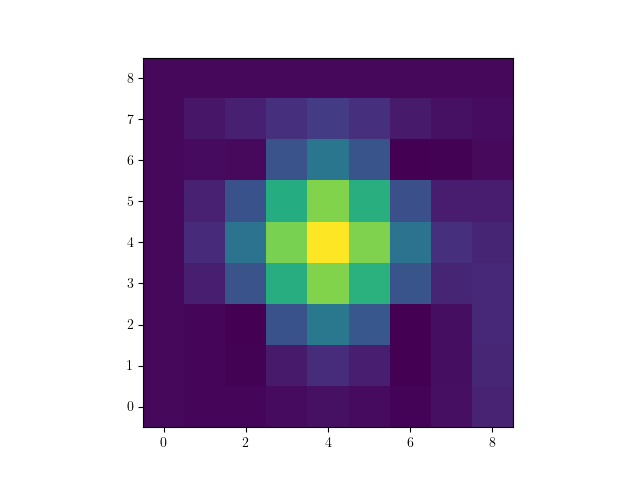

In [9]:
epsf_data = epsf_data_creation(test_case, path = '/Users/zgl12/Modules/Kakapo/', overwrite = False, stop_cond = 3000, sampling = 1)

plt.figure()
plt.imshow(epsf_data, origin = 'lower')
plt.show()

In [ ]:
# temp_data = test_case[4].flux.value[-5]
# temp_data_err = test_case[4].flux_err.value[-5]
# temp_data[temp_data < 0] = 0.1

# texp = np.nanmedian(np.diff(test_case[4].time.value)) * 24 * 60 * 60

# # print(texp)

# plt.figure()
# plt.imshow(temp_data*texp, origin = 'lower')
# plt.show()

# plt.figure()
# plt.imshow(temp_data_err, origin = 'lower')
# plt.show()

# test_noise = np.sqrt((np.sqrt(temp_data*texp)/texp)**2 + (95/texp)**2 + 1.285**2)

# plt.figure()
# plt.imshow(test_noise - temp_data_err, origin = 'lower')
# plt.show()

# print(np.nanmedian(test_noise - temp_data_err))

In [ ]:
# bkgs = []
# timings = []

# for i in range(len(test_case[4].flux.value)):

#     temp_data = test_case[4].flux.value[i]
#     temp_data_err = test_case[4].flux_err.value[i]
#     temp_data[temp_data < 0] = 0.05

#     texp = np.nanmedian(np.diff(test_case[4].time.value)) * 24 * 60 * 60
    
#     bkg = np.nanmedian(np.sqrt(temp_data_err**2 - (np.sqrt(temp_data*texp)/texp)**2 - (95/texp)**2))
    
#     if np.isfinite(bkg) & np.isfinite(test_case[4].time.value[i]):
#         timings.append(test_case[4].time.value[i])
#         bkgs.append(bkg)
    
# bkgs = np.array(bkgs)
# timings = np.array(timings)

In [ ]:
# np.nansum(~np.isfinite(timings))

In [ ]:
# from scipy.interpolate import UnivariateSpline

# B = UnivariateSpline(timings, bkgs, k=3, s=0)(timings)
# B = np.maximum(B, np.nanpercentile(B, 5))  # avoid zeros/negatives

In [ ]:
# plt.figure()
# plt.plot(timings, bkgs/np.nanpercentile(bkgs, 2))
# # plt.plot(timings, cubic_law(timings, *popt), color = 'r')
# # plt.plot(timings, B)
# # plt.plot(timings, cubic_law(timings, *[3e-5, 1.7, 1, np.nanmin(timings), 1.1975]), color = 'r')
# plt.show()

In [ ]:
# from scipy.optimize import curve_fit

# def exp_model(t, a, b, c, d):
    
#     return a*np.exp(t-d) + c

# def power_law(t, a, b, c, d):
    
#     return a*(t-d)**b + c

# def cubic_law(t, a, b, c, d, e, f, g):
    
#     y = a*(t-d)**3 + b*(t-d)**2 + c*(t-d) + e #+ g*(t-d)**5 + f*(t-d)**4
#     return y

# popt, pcov = curve_fit(cubic_law, timings, bkgs, p0 = [3e-5, 1.7, 1, np.nanmin(timings), 1.1975, 1, 1])

In [ ]:
# plt.figure()
# plt.plot(timings, bkgs)
# plt.plot(timings, cubic_law(timings, *popt), color = 'r')
# # plt.plot(timings, cubic_law(timings, *[3e-5, 1.7, 1, np.nanmin(timings), 1.1975]), color = 'r')
# plt.show()

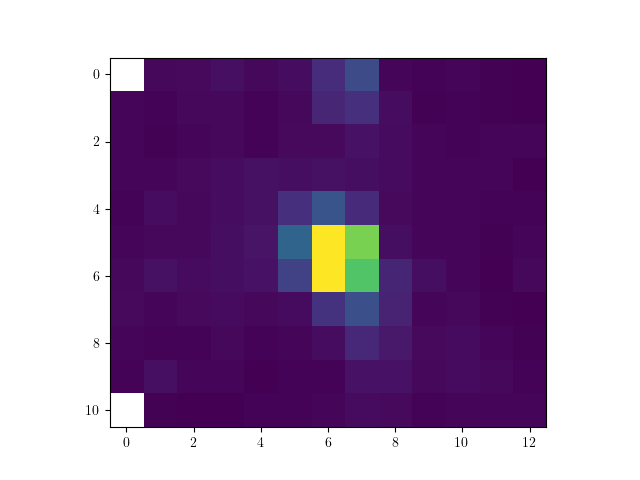

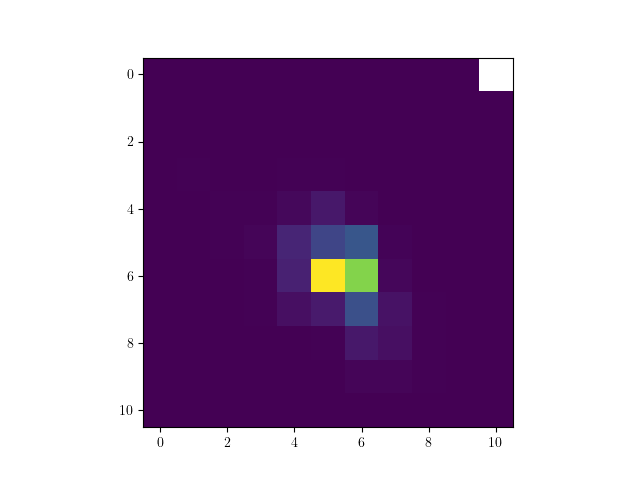

In [10]:
plt.figure()
plt.imshow(test_case[5][0].flux.value.squeeze())
plt.show()

plt.figure()
plt.imshow(test_case[6][0].flux.value.squeeze())
plt.show()

In [17]:
def diffing(filename = None, x = None, y = None, ind = None, comp = False, save = False, name = 'test'):

    diff = np.load(filename)
    
    if comp:
        diff_load = np.load('/Users/zgl12/Modules/Kakapo/Data/difference_arrays/c3/diff_c3_t205922648.npy')
        # diff_load = np.load('/Users/zgl12/Modules/Kakapo/Data/difference_arrays/c3/diff_c3_t205922735.npy')
        # diff_load = np.load('/Users/zgl12/Modules/Kakapo/Data/difference_arrays/c3/diff_c3_t205923133.npy')
        flux_opt = forced_photometry(diff_load, x, y, None)

    input_time = test_case[ind].time.value

    bjds_utc = input_time + 54832.5
    t_bary = Time(bjds_utc, format="mjd", scale="tdb")
    t_mjd_utc = t_bary.utc.mjd

    fluxes = forced_photometry(diff, x, y, None)

    mask = np.isfinite(input_time) & np.isfinite(fluxes) & (input_time != 0)

    campaign = test_case[ind].campaign
    targetid = test_case[ind].targetid

    max_lim = np.nanpercentile(fluxes, 99.5)*1.1
    min_lim = max(np.nanpercentile(fluxes, 0.5) * 0.9, -200)

    fig, axs = plt.subplots(1, 1, figsize = [fig_width, fig_height])
    plt.subplots_adjust(hspace=0.13)
        
    axs.plot(t_mjd_utc[mask], fluxes[mask], color = 'C0')
    if comp:
        attempt_mask = np.isfinite(input_time) & np.isfinite(flux_opt) & (input_time != 0)
        axs.scatter(t_mjd_utc[attempt_mask], flux_opt[attempt_mask], color = 'k', s = 10, alpha = 0.1, zorder = 10)
        lc_sm, _ = gauss_smooth(t_mjd_utc[attempt_mask], flux_opt[attempt_mask])
        axs.scatter(t_mjd_utc[attempt_mask], lc_sm, color = 'r', s = 5, alpha = 0.1, zorder = 20)

    axs.set_xlabel('Time (MJD)')
    axs.set_ylabel('Counts')

    unique, counts = np.unique(t_mjd_utc, return_counts=True)
    mjds_temp = unique[counts == 1]

    axs.set_xlim(min(mjds_temp), max(mjds_temp))
    axs.set_ylim(min_lim, max_lim)

    axs.set_title(f'c{campaign} t{targetid}')

    axs.text((max(mjds_temp) - min(mjds_temp))/10 + min(mjds_temp), 
                max_lim / 1.1, f'x: {x:.2f}, y: {y:.2f}')

    if save:
        plt.savefig(name + '.png', dpi = 800, bbox_inches='tight')
    plt.show()

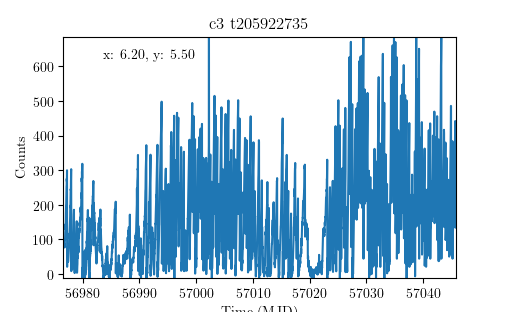

In [12]:
diffing(filename = '/Users/zgl12/Modules/Kakapo/crap_diff_image_t205922735_c3.npy', 
        x = 6.2, y = 5.5, ind = 5, save = False, name = 'star1_before')

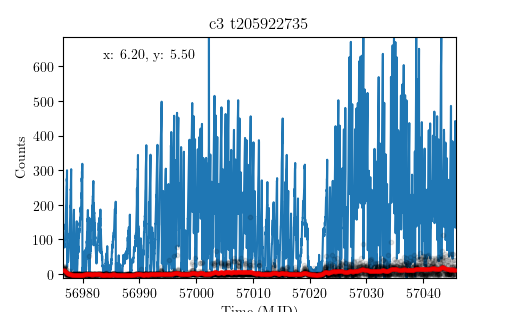

In [13]:
diffing(filename = '/Users/zgl12/Modules/Kakapo/crap_diff_image_t205922735_c3.npy', 
        x = 6.2, y = 5.5, ind = 5, comp = True, save = False, name = 'star1_after')

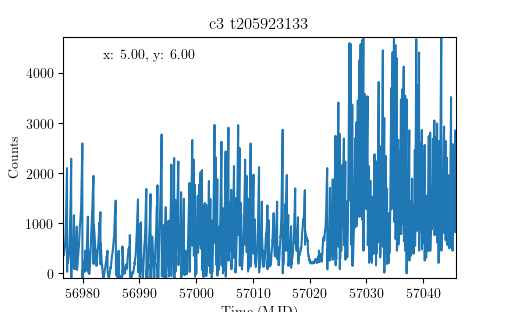

In [15]:
diffing(filename = '/Users/zgl12/Modules/Kakapo/crap_diff_image_t205923133_c3.npy', 
        x = 5, y = 6, ind = 6, comp = False, save = False, name = 'star2_before')

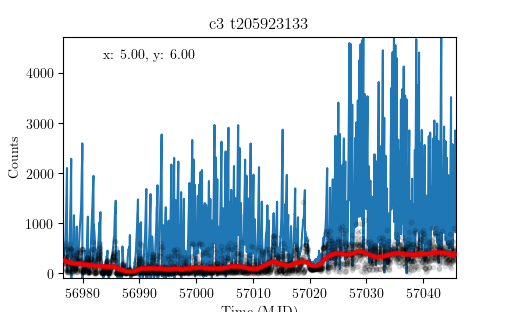

In [16]:
diffing(filename = '/Users/zgl12/Modules/Kakapo/crap_diff_image_t205923133_c3.npy', 
        x = 5, y = 6, ind = 6, comp = True, save = False, name = 'star2_after')

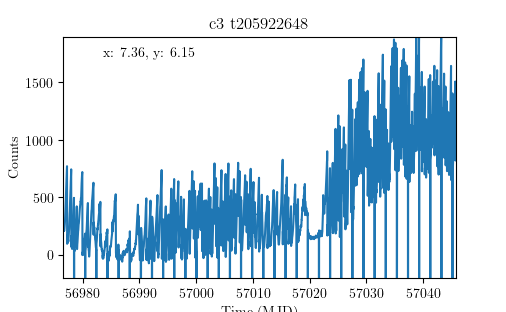

In [18]:
diffing(filename = '/Users/zgl12/Modules/Kakapo/crap_diff_image_t205922648_c3.npy', 
        x = 7.36, y = 6.15, ind = 4, comp = False, save = False, name = 'SNe_comp_before')

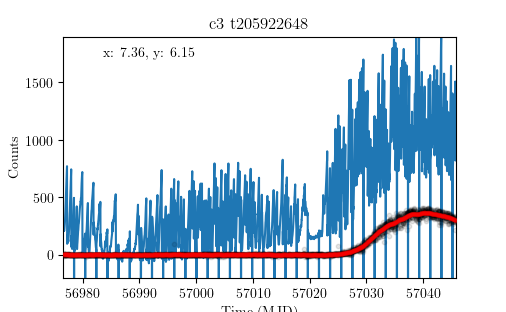

In [20]:
diffing(filename = '/Users/zgl12/Modules/Kakapo/crap_diff_image_t205922648_c3.npy', 
        x = 7.36, y = 6.15, ind = 4, comp = True, save = False, name = 'SNe_comp_after')

In [ ]:
# uno_reverse()

# kea = Kakapo(test_case[4:], epsf_data[2:-2, 2:-2], num_cores = 1, 
#              filtered = True, overwrite = False, savepath = './Data/',
#              tol = 0.2, std1 = 2, std2 = 2, detect = True, 
#              corrlim = 0.05, difflim = 1.1, fwhmlim = 5, maxlim = 0, snrlim = 4,
#              roundness = 0.95, poiss_val = 2, siglim = 2, dist_cut = 0.9,
#              break_point = 1)


